# Initial Setups

## Imports + Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib as plt
import gutenbergpy
import os
import json
import time
import requests


from gutenbergpy.textget import get_text_by_id, strip_headers
from gutenbergpy.gutenbergcache import GutenbergCache, GutenbergCacheSettings

In [3]:
data_dir = os.path.abspath(os.path.join("..", "data", "gutenberg_catalog_cache"))

GutenbergCacheSettings.set(
    CacheFilename=os.path.join(data_dir, "gutenbergindex.db"),
    CacheUnpackDir=os.path.join(data_dir, "epub"),
)


print(GutenbergCacheSettings.CACHE_FILENAME)
print(GutenbergCacheSettings.CACHE_RDF_UNPACK_DIRECTORY)


/Users/ethanleitch/Documents/Coding_Projects/Socrates_AI/data/gutenberg_catalog_cache/gutenbergindex.db
/Users/ethanleitch/Documents/Coding_Projects/Socrates_AI/data/gutenberg_catalog_cache/epub


In [4]:
# GutenbergCache.create(
#     refresh=False,
#     download=False,
#     unpack=False,
#     parse=True,
#     cache=True,
#     deleteTemp=True,
# )

## Creating the Gutenberg cache files

In [5]:
# GutenbergCache.create(
#     refresh=True,
#     download=True,
#     unpack=True,
#     parse=True,
#     cache=True,
#     deleteTemp=True,
# )

# Data

## Sanity checks

In [ ]:
db_path = os.path.join("..", "data", "gutenberg_catalog_cache", "gutenbergindex.db")
print(os.path.exists(db_path))
print(os.path.getsize(db_path))

In [7]:
cache = GutenbergCache.get_cache()
print(cache.native_query("SELECT COUNT(*) FROM books").fetchall())

[(78965,)]


In [ ]:
tables = cache.native_query("SELECT name FROM sqlite_master WHERE type='table'")
print([t[0] for t in tables])

In [ ]:
cols = cache.native_query("PRAGMA table_info(books)")
for c in cols:
    print(c) 

In [ ]:
for t in ["titles", "authors", "book_authors", "subjects", "book_subjects"]:
    cols = cache.native_query(f"PRAGMA table_info({t})")
    print(f"--- {t} ---")
    for c in cols:
        print(c)

## Creating new datasets

In [8]:
books = pd.DataFrame(
    cache.native_query("SELECT * FROM books").fetchall(),
    columns=[
        "id",
        "publisherid",
        "dateissued",
        "rightsid",
        "numdownloads",
        "languageid",
        "bookshelfid",
        "gutenbergbookid",
        "typeid",
    ],
)

titles = pd.DataFrame(
    cache.native_query("SELECT * FROM titles").fetchall(),
    columns=["id", "name", "bookid"],
)

authors = pd.DataFrame(
    cache.native_query("SELECT * FROM authors").fetchall(),
    columns=["id", "name"],
)

subjects = pd.DataFrame(
    cache.native_query("SELECT * FROM subjects").fetchall(),
    columns=["id", "name"],
)

languages = pd.DataFrame(
    cache.native_query("SELECT * FROM languages").fetchall(),
    columns=["id", "name"],
)

publishers = pd.DataFrame(
    cache.native_query("SELECT * FROM publishers").fetchall(),
    columns=["id", "name"],
)

rights = pd.DataFrame(
    cache.native_query("SELECT * FROM rights").fetchall(),
    columns=["id", "name"],
)

types = pd.DataFrame(
    cache.native_query("SELECT * FROM types").fetchall(),
    columns=["id", "name"],
)

bookshelves = pd.DataFrame(
    cache.native_query("SELECT * FROM bookshelves").fetchall(),
    columns=["id", "name"],
)

downloadlinks = pd.DataFrame(
    cache.native_query("SELECT * FROM downloadlinks").fetchall(),
    columns=["id", "name", "downloadtypeid", "bookid"],
)

downloadlinkstype = pd.DataFrame(
    cache.native_query("SELECT * FROM downloadlinkstype").fetchall(),
    columns=["id", "name"],
)

book_authors = pd.DataFrame(
    cache.native_query("SELECT * FROM book_authors").fetchall(),
    columns=["bookid", "authorid"],
)

book_subjects = pd.DataFrame(
    cache.native_query("SELECT * FROM book_subjects").fetchall(),
    columns=["bookid", "subjectid"],
)

In [ ]:
books.head()

In [ ]:
titles[titles.bookid == 61804]

In [ ]:
book_subjects[book_subjects.bookid == 44658]


In [ ]:
languages[languages.id == 1]

In [ ]:
books[books.gutenbergbookid == 27942]

In [ ]:
types

In [ ]:
books[books.gutenbergbookid == 1497].id.values[0]

## Loading in raw data + metadata creation

In [9]:
query = """
SELECT b.gutenbergbookid, b.numdownloads, bs.name, MIN(t.name) AS title
FROM books b
JOIN bookshelves bs ON bs.id = b.bookshelveid
JOIN titles t ON t.bookid = b.id
JOIN types ty ON ty.id = b.typeid
JOIN languages l ON l.id = b.languageid
WHERE bs.name = 'Philosophy'
  AND ty.name = 'Text'
  AND l.name = 'en'
GROUP BY b.id
ORDER BY b.numdownloads DESC
LIMIT 50
"""
results = cache.native_query(query).fetchall()
for r in results:
    print(r)

(1998, 25562, 'Philosophy', 'Also sprach Zarathustra. English')
(4363, 20703, 'Philosophy', 'Beyond Good and Evil')
(1497, 17172, 'Philosophy', 'The Republic')
(27942, 14956, 'Philosophy', 'A System of Logic, Ratiocinative and Inductive')
(26495, 11988, 'Philosophy', 'A System of Logic, Ratiocinative and Inductive (Vol. 1 of 2)')
(4280, 10972, 'Philosophy', 'The Critique of Pure Reason')
(34901, 10135, 'Philosophy', 'On Liberty')
(5827, 9852, 'Philosophy', 'The Problems of Philosophy')
(3800, 9340, 'Philosophy', 'Ethica Ordine Geometrico Demonstrata')
(25110, 9287, 'Philosophy', 'The Approach to Philosophy')
(27597, 8195, 'Philosophy', 'The English Utilitarians, Volume 1 (of 3)')
(25447, 8121, 'Philosophy', 'Mysticism and Logic and Other Essays')
(22364, 7858, 'Philosophy', 'The Philosophy of the Moral Feelings')
(852, 7694, 'Philosophy', 'Democracy and Education: An Introduction to the Philosophy of Education')
(25012, 6435, 'Philosophy', 'The Case of Wagner, Nietzsche Contra Wagner, 

In [10]:
top_50_philosophy_ids = [r[0] for r in results]
print(top_50_philosophy_ids)

[1998, 4363, 1497, 27942, 26495, 4280, 34901, 5827, 3800, 25110, 27597, 25447, 22364, 852, 25012, 4705, 19322, 37090, 11224, 22283, 4320, 1726, 1642, 4352, 23422, 6798, 1635, 2529, 28696, 1016, 989, 4723, 11100, 25172, 35722, 690, 32547, 4763, 11984, 5717, 4391, 990, 7514, 31796, 992, 6366, 12004, 32168, 17556, 16833]


In [11]:

def fetch_book_text(book_id):
    """
    Custom fetch funciton for when get_text_by_id() fails
    """
    urls_to_try = [
        f"https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt",
        f"https://www.gutenberg.org/files/{book_id}/{book_id}.txt",
        f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt",
    ]
    for url in urls_to_try:
        resp = requests.get(url)
        if resp.status_code == 200:
            raw_bytes = resp.content
            try:
                return raw_bytes.decode("utf-8")
            except UnicodeDecodeError:
                return raw_bytes.decode("latin-1")  # latin-1 never fails, maps every byte 0-255
    raise ValueError(f"Could not fetch text for {book_id}")

text = fetch_book_text(35722)
print(len(text))

1302171


In [16]:
output_dir = os.path.join("..", "data", "raw_books")


In [ ]:
output_dir = os.path.join("..", "data", "raw_books")
os.makedirs(output_dir, exist_ok=True)

metadata_path = os.path.join("..", "data", "metadata.json")
metadata = {}

# --- Step 1: gather metadata + confirm bookshelf ---
for book_id in top_50_philosophy_ids:
    title_query = f"""
    SELECT t.name, bs.name
    FROM books b
    JOIN titles t ON t.bookid = b.id
    JOIN bookshelves bs ON bs.id = b.bookshelveid
    WHERE b.gutenbergbookid = {book_id}
    """
    results = cache.native_query(title_query).fetchall()
    title = results[0][0] if results else "UNKNOWN"
    bookshelf = results[0][1] if results else "UNKNOWN"

    author_query = f"""
    SELECT a.name
    FROM books b
    JOIN book_authors ba ON ba.bookid = b.id
    JOIN authors a ON a.id = ba.authorid
    WHERE b.gutenbergbookid = {book_id}
    """
    author_results = cache.native_query(author_query).fetchall()
    authors = [r[0] for r in author_results]

    is_philosophy = bookshelf == "Philosophy"
    flag = "✓" if is_philosophy else "✗ CHECK THIS ONE"

    print(f"{book_id}: {title} — {authors} — {bookshelf} {flag}")

    metadata[book_id] = {
        "title": title,
        "authors": authors,
        "bookshelf": bookshelf,
        "is_flagged_philosophy": is_philosophy,
        "filename": f"{book_id}.txt",
    }

# --- Step 2: download texts ---
for book_id in top_50_philosophy_ids:
    filepath = os.path.join(output_dir, f"{book_id}.txt")

    if os.path.exists(filepath):
        print(f"Skipping {book_id}, already downloaded")
        metadata[book_id]["char_count"] = os.path.getsize(filepath)
        continue

    try:
        try:
            raw = get_text_by_id(book_id)
            text = strip_headers(raw).decode("utf-8", errors="ignore")
        except UnicodeDecodeError as e:
            print(f"gutenbergpy encoding failed on {book_id} ({e}), trying direct download...")
            text = fetch_book_text(book_id)

        with open(filepath, "w", encoding="utf-8") as f:
            f.write(text)

        metadata[book_id]["char_count"] = len(text)
        print(f"Saved {book_id} ({len(text)} chars)")

    except Exception as e:
        print(f"Failed on {book_id}: {e}")
        metadata[book_id]["char_count"] = None
        metadata[book_id]["error"] = str(e)

    time.sleep(1)

# --- Step 3: save metadata ---
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"\nMetadata saved to {metadata_path}")
print(f"Texts saved to {output_dir}")

# Data Cleaning

## Cleaning functions

In [ ]:
import re
import unicodedata

START_RE = re.compile(r"^.*start of (?:the|this) project gutenberg.*$", re.IGNORECASE | re.MULTILINE)
END_RE = re.compile(r"^.*end of (?:the|this) project gutenberg.*$", re.IGNORECASE | re.MULTILINE)


def strip_gutenberg_boilerplate(text):
    """
    Removes Project Gutenberg header/footer boilerplate.
    gutenbergpy's strip_headers() already handles most files, but the
    requests-based fallback in fetch_book_text() does not, so this has
    to stay idempotent for already-stripped text.
    """
    start_match = START_RE.search(text)
    if start_match:
        text = text[start_match.end():]

    end_match = END_RE.search(text)
    if end_match:
        text = text[:end_match.start()]

    return text.strip()


def clean_text(text):
    """
    Light normalisation for LM training data. Keeps wording/punctuation
    intact, only touches encoding artifacts and whitespace.
    """
    text = text.lstrip("﻿")  # BOM from some direct downloads
    text = strip_gutenberg_boilerplate(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+\n", "\n", text)      # trailing whitespace per line
    text = re.sub(r"\n{3,}", "\n\n", text)      # collapse 3+ blank lines to 1
    return text.strip()

## Apply cleaning to all books

In [39]:
clean_dir = os.path.join("..", "data", "clean_books")
os.path.abspath("..")

'/Users/ethanleitch/Documents/Coding_Projects/Socrates_AI'

In [ ]:
clean_dir = os.path.join("..", "data", "clean_books")
os.makedirs(clean_dir, exist_ok=True)

with open(metadata_path, encoding="utf-8") as f:
    metadata = json.load(f)

for book_id, info in metadata.items():
    if info.get("char_count") is None:
        continue  # download failed for this book, nothing to clean

    raw_path = os.path.join(output_dir, info["filename"])
    clean_path = os.path.join(clean_dir, info["filename"])

    with open(raw_path, encoding="utf-8") as f:
        raw_text = f.read()

    cleaned = clean_text(raw_text)

    with open(clean_path, "w", encoding="utf-8") as f:
        f.write(cleaned)

    info["clean_char_count"] = len(cleaned)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Cleaned {sum(1 for i in metadata.values() if 'clean_char_count' in i)} books -> {clean_dir}")

## Data checks

In [14]:
metadata_path = os.path.join("..", "data", "metadata.json")

with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

In [17]:
# Check 1: missing raw files / failed downloads
missing_raw = [
    bid for bid, info in metadata.items()
    if not os.path.exists(os.path.join(output_dir, info["filename"]))
]
failed_downloads = [bid for bid, info in metadata.items() if info.get("error")]

print(f"Missing raw files: {missing_raw}")
print(f"Books with download errors: {failed_downloads}")

Missing raw files: []
Books with download errors: []


In [18]:
# Check 2: suspiciously short cleaned texts (likely a bad download or over-aggressive strip)
SHORT_CHAR_THRESHOLD = 5000

short_books = {
    bid: info["clean_char_count"]
    for bid, info in metadata.items()
    if info.get("clean_char_count", 0) < SHORT_CHAR_THRESHOLD
}

print(f"Books below {SHORT_CHAR_THRESHOLD} chars after cleaning:")
for bid, count in short_books.items():
    print(f"  {bid}: {metadata[bid]['title']} ({count} chars)")

Books below 5000 chars after cleaning:


In [21]:
# Check 3: leftover Gutenberg boilerplate after cleaning
leftover_boilerplate = []
for book_id, info in metadata.items():
    if "clean_char_count" not in info:
        continue
    with open(os.path.join(clean_dir, info["filename"]), encoding="utf-8") as f:
        text = f.read()
    head, tail = text[:500].upper(), text[-500:].upper()
    if "PROJECT GUTENBERG" in head or "PROJECT GUTENBERG" in tail:
        leftover_boilerplate.append(book_id)

print(f"Books with possible leftover boilerplate: {leftover_boilerplate}")

Books with possible leftover boilerplate: []


In [22]:
# Check 4: non-English books (the "Philosophy" bookshelf query wasn't language-filtered)
book_ids_str = ",".join(str(bid) for bid in metadata.keys())
lang_query = f"""
SELECT b.gutenbergbookid, l.name
FROM books b
JOIN languages l ON l.id = b.languageid
WHERE b.gutenbergbookid IN ({book_ids_str})
"""
non_english = [(bid, lang) for bid, lang in cache.native_query(lang_query).fetchall() if lang != "en"]

print(f"Non-English books: {non_english}")

Non-English books: []


In [23]:
# Check 5: exact duplicate texts (same cleaned content saved under two ids)
import hashlib

seen_hashes = {}
exact_duplicates = []
for book_id, info in metadata.items():
    if "clean_char_count" not in info:
        continue
    with open(os.path.join(clean_dir, info["filename"]), encoding="utf-8") as f:
        text = f.read()
    text_hash = hashlib.md5(text.encode("utf-8")).hexdigest()
    if text_hash in seen_hashes:
        exact_duplicates.append((seen_hashes[text_hash], book_id))
    else:
        seen_hashes[text_hash] = book_id

print(f"Exact duplicate texts: {exact_duplicates}")

Exact duplicate texts: []


In [24]:
# Check 6: near-duplicate/overlapping works (same author, highly similar titles —
# e.g. a full multi-volume work alongside one of its individual volumes)
from difflib import SequenceMatcher

items = list(metadata.items())
near_duplicates = []
for i in range(len(items)):
    for j in range(i + 1, len(items)):
        bid_a, info_a = items[i]
        bid_b, info_b = items[j]
        if set(info_a["authors"]) & set(info_b["authors"]):
            similarity = SequenceMatcher(None, info_a["title"], info_b["title"]).ratio()
            if similarity > 0.5:
                near_duplicates.append(
                    (bid_a, info_a["title"], bid_b, info_b["title"], round(similarity, 2))
                )

print("Possible duplicate/overlapping works (verify manually before excluding):")
for d in near_duplicates:
    print(f"  {d[0]} {d[1]!r}  <->  {d[2]} {d[3]!r}  (similarity={d[4]})")

Possible duplicate/overlapping works (verify manually before excluding):
  27942 'A System of Logic, Ratiocinative and Inductive'  <->  26495 'A System of Logic, Ratiocinative and Inductive (Vol. 1 of 2)'  (similarity=0.87)
  28696 'Symbolic Logic'  <->  4763 'The Game of Logic'  (similarity=0.52)
  989 'Theologico-Political Treatise — Part 1'  <->  990 'Theologico-Political Treatise — Part 2'  (similarity=0.97)
  989 'Theologico-Political Treatise — Part 1'  <->  992 'A Theological-Political Treatise [Part IV]'  (similarity=0.85)
  990 'Theologico-Political Treatise — Part 2'  <->  992 'A Theological-Political Treatise [Part IV]'  (similarity=0.85)


## Cleaned text length distribution

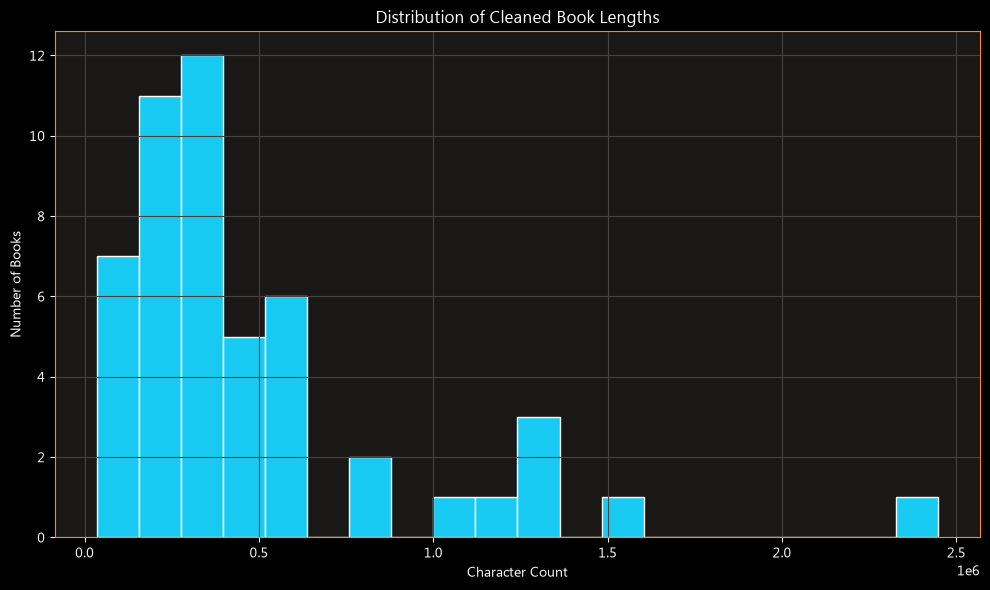

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

clean_counts = pd.Series(
    {bid: info["clean_char_count"] for bid, info in metadata.items() if "clean_char_count" in info}
)

plt.rcParams["font.family"] = "Microsoft Tai Le"
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#1A1817")

sns.histplot(clean_counts, bins=20, color="#18D5FFFF", ax=ax, alpha=0.95)

ax.grid(True, color="#444444", linewidth=0.8)
for spine in ax.spines.values():
    spine.set_color("#FF8818")

ax.set_title("Distribution of Cleaned Book Lengths")
ax.set_xlabel("Character Count")
ax.set_ylabel("Number of Books")

plt.tight_layout()
plt.show()

# Exploratory Data Analysis

Per-book character length is already covered above (`Cleaned text length distribution`). This section looks at the training corpus from a few other angles: total size as books are added, vocabulary richness, and sentence structure.

## Total corpus size over time

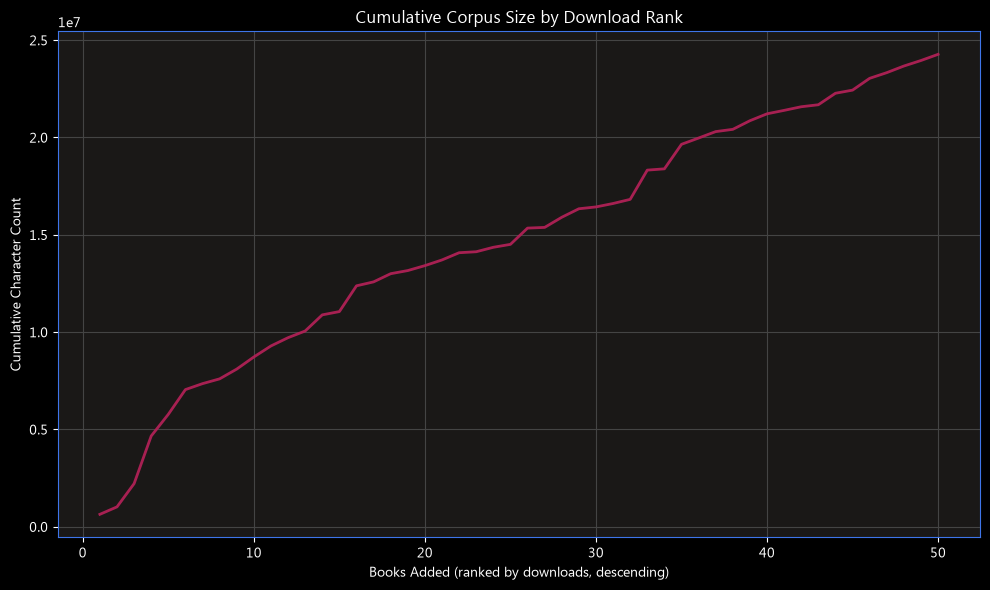

Total corpus size: 24,272,895 characters across 50 books


In [26]:
# Cumulative character count as books are "added" in download-rank order,
# i.e. how much training text we'd have if we stopped at book N
ranked_ids = [str(bid) for bid in top_50_philosophy_ids if str(bid) in metadata]
cumulative_chars = pd.Series(
    [metadata[bid]["clean_char_count"] for bid in ranked_ids]
).cumsum()

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#1A1817")

ax.plot(range(1, len(ranked_ids) + 1), cumulative_chars, color="#B02156FF", alpha=0.95, linewidth=2)

ax.grid(True, color="#444444", linewidth=0.8)
for spine in ax.spines.values():
    spine.set_color("#3E75EA")

ax.set_title("Cumulative Corpus Size by Download Rank")
ax.set_xlabel("Books Added (ranked by downloads, descending)")
ax.set_ylabel("Cumulative Character Count")

plt.tight_layout()
plt.show()

print(f"Total corpus size: {cumulative_chars.iloc[-1]:,} characters across {len(ranked_ids)} books")

## Word count, vocabulary size & sentence length per book

In [ ]:
# Simple regex-based word/sentence splitting is enough for EDA-level sanity checks —
# no need to pull in a full tokeniser (nltk/spacy) just to eyeball the corpus.
WORD_RE = re.compile(r"[A-Za-z']+")
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")

eda_rows = []
for book_id, info in metadata.items():
    with open(os.path.join(clean_dir, info["filename"]), encoding="utf-8") as f:
        text = f.read()

    words = WORD_RE.findall(text.lower())
    # drop very short fragments (chapter numbers, headings) that aren't real sentences
    sentences = [s for s in SENTENCE_SPLIT_RE.split(text) if len(s.split()) > 2]

    eda_rows.append({
        "book_id": book_id,
        "title": info["title"],
        "word_count": len(words),
        "unique_word_count": len(set(words)),
        "lexical_diversity": len(set(words)) / len(words) if words else 0,
        "sentence_count": len(sentences),
        "avg_sentence_length": len(words) / len(sentences) if sentences else 0,
    })

eda_df = pd.DataFrame(eda_rows).set_index("book_id")
eda_df.sort_values("word_count", ascending=False)

## Vocabulary richness per book

Lexical diversity (unique words / total words) naturally falls as a book gets longer, since long books repeat words more — so this is more useful for comparing similarly-sized books than as an absolute score. Still a useful sanity check for oddly narrow vocabularies (e.g. some translations).

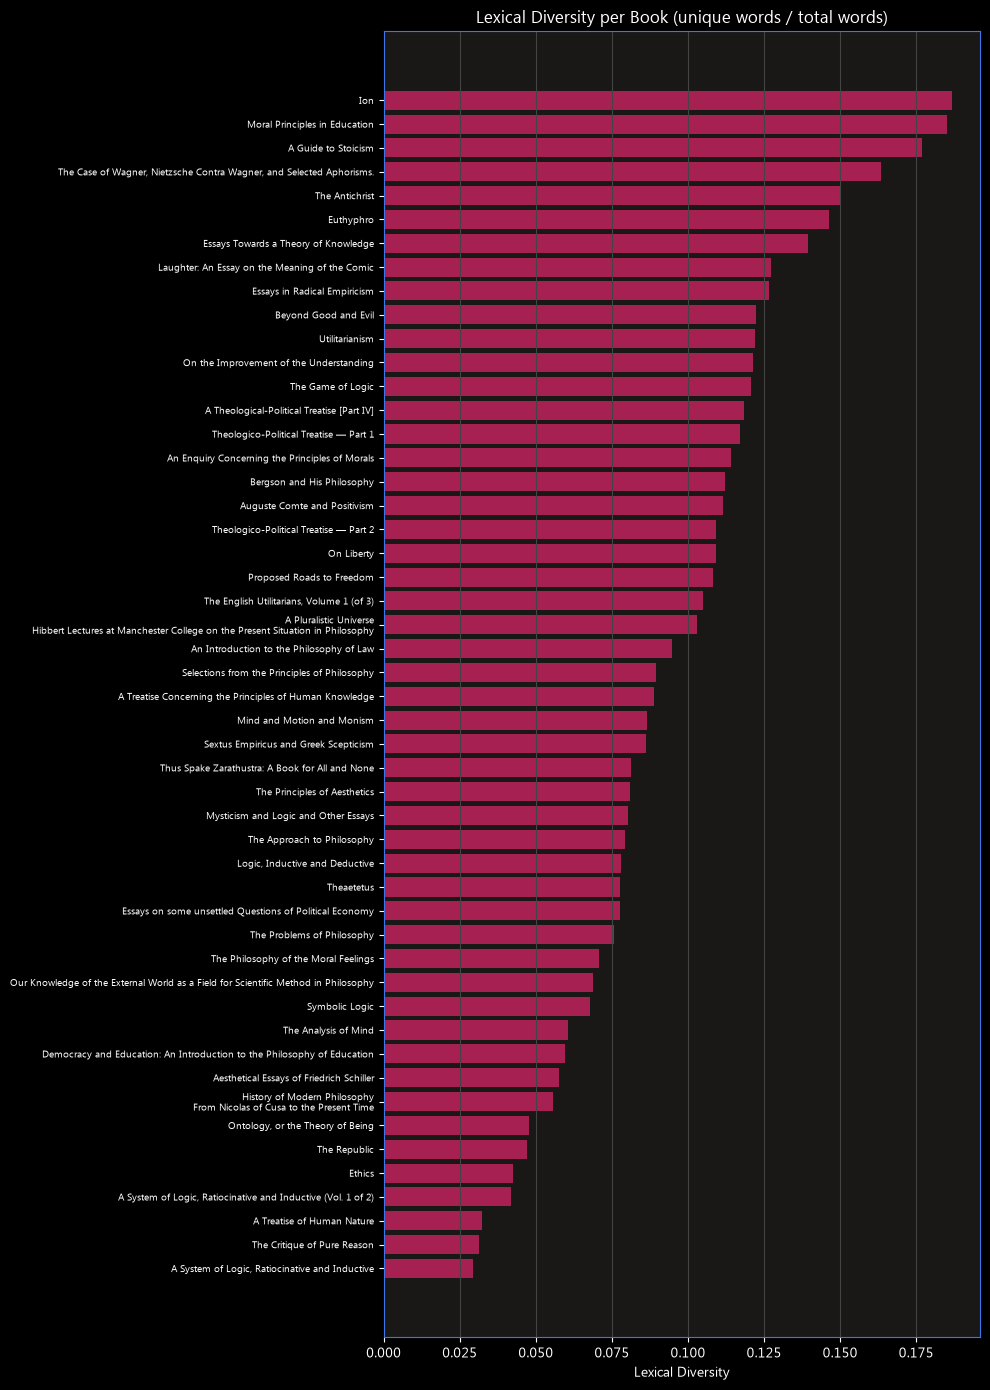

In [28]:
plot_df = eda_df.sort_values("lexical_diversity")

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 14))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#1A1817")

ax.barh(plot_df["title"], plot_df["lexical_diversity"], color="#B02156FF", alpha=0.95)

ax.grid(True, color="#444444", linewidth=0.8, axis="x")
for spine in ax.spines.values():
    spine.set_color("#3E75EA")

ax.set_title("Lexical Diversity per Book (unique words / total words)")
ax.set_xlabel("Lexical Diversity")
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

## Average sentence length per book

A quick style sanity check before training — aphoristic writers (Nietzsche) should sit at the short end, writers known for dense, clause-heavy prose (Kant) at the long end.

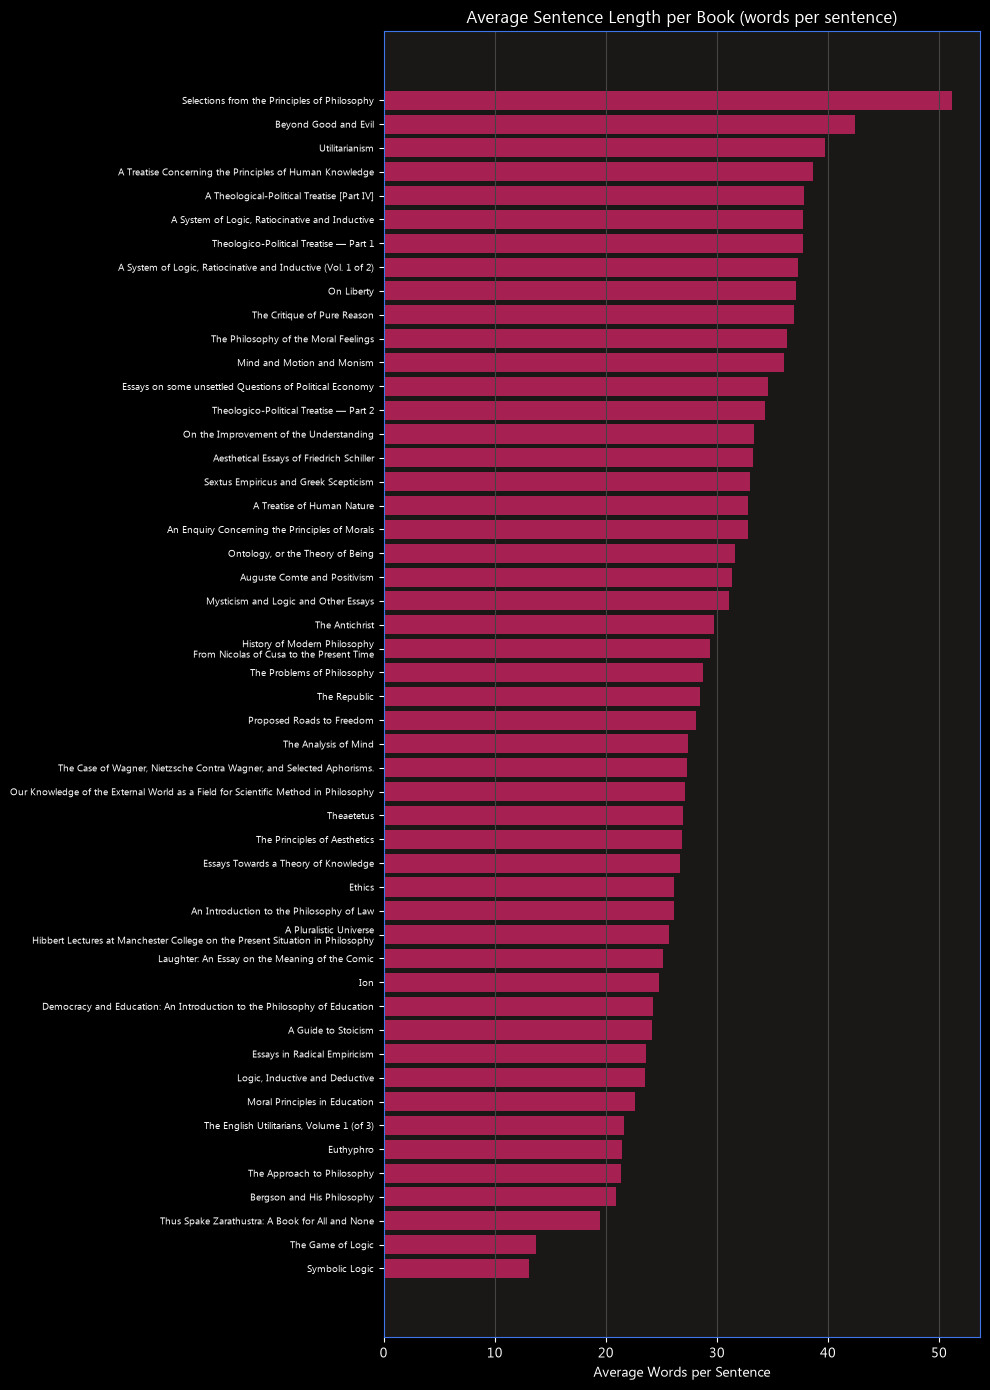

In [29]:
plot_df = eda_df.sort_values("avg_sentence_length")

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 14))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#1A1817")

ax.barh(plot_df["title"], plot_df["avg_sentence_length"], color="#B02156FF", alpha=0.95)

ax.grid(True, color="#444444", linewidth=0.8, axis="x")
for spine in ax.spines.values():
    spine.set_color("#3E75EA")

ax.set_title("Average Sentence Length per Book (words per sentence)")
ax.set_xlabel("Average Words per Sentence")
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

In [35]:
GutenbergCache.exists()

True

# Class creation for loading + cleaning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gutenbergpy
import os
import json
import time
import requests


from gutenbergpy.gutenbergcache import GutenbergCache, GutenbergCacheSettings
from socrates_ai.helpers import fetch_book_text, get_book_titles, get_author_info, download_bookid
from socrates_ai.resources import TOP_50_PHILOSOPHY_QUERY


class TheFarmer:
    def __init__(self):
        self.num_books = 50
        self.created_cache = GutenbergCache.exists()
        self.cache = None

    def set_data_destination(self):
        data_dir = os.path.abspath(os.path.join("..", "data", "gutenberg_catalog_cache"))
        GutenbergCacheSettings.set(
            CacheFilename=os.path.join(data_dir, "gutenbergindex.db"),
            CacheUnpackDir=os.path.join(data_dir, "epub"),
        )
        print("Storing cache data at:")
        print(GutenbergCacheSettings.CACHE_FILENAME)
        print(GutenbergCacheSettings.CACHE_RDF_UNPACK_DIRECTORY)

    def retrieve_gutenberg_books(self):
        if self.created_cache:
            print("Cache has already been created ensure .db & epub files are in gutenberg_cataglog_cache ")
        else:
            GutenbergCache.create(
                refresh=True,
                download=True,
                unpack=True,
                parse=True,
                cache=True,
                deleteTemp=True,
            )
        self.cache = GutenbergCache.get_cache()

    def farm_philosophy_books(self):
        query_results = self.cache.native_query(TOP_50_PHILOSOPHY_QUERY).fetchall()
        top_50_philosophy_ids = [r[0] for r in query_results]

        output_dir = os.path.join("..", "data", "raw_books")
        os.makedirs(output_dir, exist_ok=True)

        metadata_path = os.path.join("..", "data", "metadata.json")
        metadata = {}
        # --- Step 1: gather metadata + confirm bookshelf ---
        for book_id in top_50_philosophy_ids:

            title, bookshelf_cat = get_book_titles(self.cache, book_id)
            authors = get_author_info(self.cache, book_id)

            is_philosophy = bookshelf_cat == "Philosophy"
            flag = "✓" if is_philosophy else "✗ CHECK THIS ONE"
            print(f"{book_id}: {title} — {authors} — {bookshelf_cat} {flag}")

            metadata[book_id] = {
                "title": title,
                "authors": authors,
                "bookshelf": bookshelf_cat,
                "is_flagged_philosophy": is_philosophy,
                "filename": f"{book_id}.txt",
            }
        # --- Step 2: download texts ---
        for book_id in top_50_philosophy_ids:
            filepath = os.path.join(output_dir, f"{book_id}.txt")

            if os.path.exists(filepath):
                print(f"Skipping {book_id}, already downloaded")
                metadata[book_id]["char_count"] = os.path.getsize(filepath)
                continue

            char_count, error = download_bookid(book_id, output_dir)
            metadata[book_id]["char_count"] = char_count
            if error is not None:
                metadata[book_id]["error"] = error

            time.sleep(1)

        # --- Step 3: save metadata ---
        with open(metadata_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)

        print(f"\nMetadata saved to {metadata_path}")
        print(f"Texts saved to {output_dir}")



In [ ]:
import re
import json
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class EDAPainter:
    """
    Produces EDA plots for the cleaned philosophy corpus.
    Assumes TheFarmer has already run — reads data/metadata.json and
    data/clean_books/ from disk, so it works standalone even in a fresh kernel.
    """

    WORD_RE = re.compile(r"[A-Za-z']+")
    SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")

    def __init__(self, metadata_path=None, clean_dir=None):
        self.metadata_path = metadata_path or os.path.join("..", "data", "metadata.json")
        self.clean_dir = clean_dir or os.path.join("..", "data", "clean_books")

        with open(self.metadata_path, encoding="utf-8") as f:
            self.metadata = json.load(f)

        self._eda_df = None  # lazily built by self.eda_df, expensive to recompute

    @property
    def eda_df(self):
        """Word/vocab/sentence stats per book, computed once and cached."""
        if self._eda_df is None:
            self._eda_df = self._build_eda_df()
        return self._eda_df

    def _build_eda_df(self):
        rows = []
        for book_id, info in self.metadata.items():
            if "clean_char_count" not in info:
                continue

            with open(os.path.join(self.clean_dir, info["filename"]), encoding="utf-8") as f:
                text = f.read()

            words = self.WORD_RE.findall(text.lower())
            sentences = [s for s in self.SENTENCE_SPLIT_RE.split(text) if len(s.split()) > 2]

            rows.append({
                "book_id": book_id,
                "title": info["title"],
                "word_count": len(words),
                "unique_word_count": len(set(words)),
                "lexical_diversity": len(set(words)) / len(words) if words else 0,
                "sentence_count": len(sentences),
                "avg_sentence_length": len(words) / len(sentences) if sentences else 0,
            })

        return pd.DataFrame(rows).set_index("book_id")

    @staticmethod
    def _new_dark_axes(figsize=(10, 6)):
        plt.style.use("dark_background")
        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor("#000000")
        ax.set_facecolor("#1A1817")
        return fig, ax

    def plot_length_distribution(self):
        """Histogram of cleaned character counts per book."""
        clean_counts = pd.Series(
            {bid: info["clean_char_count"] for bid, info in self.metadata.items() if "clean_char_count" in info}
        )

        fig, ax = self._new_dark_axes()
        sns.histplot(clean_counts, bins=20, color="#18D5FFFF", ax=ax, alpha=0.95)

        ax.grid(True, color="#444444", linewidth=0.8)
        for spine in ax.spines.values():
            spine.set_color("#FF8818")

        ax.set_title("Distribution of Cleaned Book Lengths")
        ax.set_xlabel("Character Count")
        ax.set_ylabel("Number of Books")

        plt.tight_layout()
        plt.show()

    def plot_cumulative_corpus_size(self):
        """
        Cumulative character count as books are "added" in download-rank order.
        Rank order comes straight from metadata's insertion order, since
        TheFarmer writes entries in the order the ranked query returned them.
        """
        ranked_ids = [bid for bid in self.metadata if "clean_char_count" in self.metadata[bid]]
        cumulative_chars = pd.Series(
            [self.metadata[bid]["clean_char_count"] for bid in ranked_ids]
        ).cumsum()

        fig, ax = self._new_dark_axes()
        ax.plot(range(1, len(ranked_ids) + 1), cumulative_chars, color="#B02156FF", alpha=0.95, linewidth=2)

        ax.grid(True, color="#444444", linewidth=0.8)
        for spine in ax.spines.values():
            spine.set_color("#3E75EA")

        ax.set_title("Cumulative Corpus Size by Download Rank")
        ax.set_xlabel("Books Added (ranked by downloads, descending)")
        ax.set_ylabel("Cumulative Character Count")

        plt.tight_layout()
        plt.show()

        print(f"Total corpus size: {cumulative_chars.iloc[-1]:,} characters across {len(ranked_ids)} books")

    def plot_lexical_diversity(self):
        """Horizontal bar chart of unique words / total words per book."""
        plot_df = self.eda_df.sort_values("lexical_diversity")

        fig, ax = self._new_dark_axes(figsize=(10, 14))
        ax.barh(plot_df["title"], plot_df["lexical_diversity"], color="#B02156FF", alpha=0.95)

        ax.grid(True, color="#444444", linewidth=0.8, axis="x")
        for spine in ax.spines.values():
            spine.set_color("#3E75EA")

        ax.set_title("Lexical Diversity per Book (unique words / total words)")
        ax.set_xlabel("Lexical Diversity")
        ax.tick_params(axis="y", labelsize=7)

        plt.tight_layout()
        plt.show()

    def plot_avg_sentence_length(self):
        """Horizontal bar chart of average words per sentence per book."""
        plot_df = self.eda_df.sort_values("avg_sentence_length")

        fig, ax = self._new_dark_axes(figsize=(10, 14))
        ax.barh(plot_df["title"], plot_df["avg_sentence_length"], color="#B02156FF", alpha=0.95)

        ax.grid(True, color="#444444", linewidth=0.8, axis="x")
        for spine in ax.spines.values():
            spine.set_color("#3E75EA")

        ax.set_title("Average Sentence Length per Book (words per sentence)")
        ax.set_xlabel("Average Words per Sentence")
        ax.tick_params(axis="y", labelsize=7)

        plt.tight_layout()
        plt.show()

In [ ]:
import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))

for font in fonts:
    print(font)